# 02_crop_ml_experiments

This notebook contains the machine learning experiments for crop classification, including model training, hyperparameter tuning, evaluation, explainability, and experiment tracking.

## 1. Setup & Imports

In [58]:
# Install required packages if not already present
!pip install -q xgboost shap mlflow

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning models & utilities
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import xgboost as xgb
import shap
import mlflow

# Configure visual settings
sns.set_theme(style="whitegrid")
%matplotlib inline

## 2. Load Prepared Data

In [59]:
import pandas as pd

# Load prepared training and testing data
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1760, 7)
X_test shape: (440, 7)
y_train shape: (1760, 1)
y_test shape: (440, 1)


## 3. Verify Train/Test Data

In [60]:
# Print sample of target classes
unique_train_labels = y_train['label'].nunique()
unique_test_labels = y_test['label'].nunique()

print(f"Number of unique crop classes in Train: {unique_train_labels}")
print(f"Number of unique crop classes in Test: {unique_test_labels}")

# Encode target labels into numerical formats for model compatibility
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train['label'].values.ravel())
y_test_encoded = le.transform(y_test['label'].values.ravel())

print("Encoded target labels summary:")
print(pd.Series(y_train_encoded).value_counts().head())

Number of unique crop classes in Train: 22
Number of unique crop classes in Test: 22
Encoded target labels summary:
16    80
7     80
9     80
13    80
6     80
Name: count, dtype: int64


## 4. Baseline Model
### Logistic Regression

In [61]:
# Train a baseline Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train_encoded)

lr_train_acc = lr_model.score(X_train, y_train_encoded)
lr_test_acc = lr_model.score(X_test, y_test_encoded)

print(f"Logistic Regression Train Accuracy: {lr_train_acc:.4f}")
print(f"Logistic Regression Test Accuracy: {lr_test_acc:.4f}")

Logistic Regression Train Accuracy: 0.9739
Logistic Regression Test Accuracy: 0.9727


## 5. Random Forest


In [62]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train_encoded)

rf_train_acc = rf_model.score(X_train, y_train_encoded)
rf_test_acc = rf_model.score(X_test, y_test_encoded)

print(f"Random Forest Train Accuracy: {rf_train_acc:.4f}")
print(f"Random Forest Test Accuracy: {rf_test_acc:.4f}")

Random Forest Train Accuracy: 1.0000
Random Forest Test Accuracy: 0.9955


##6. XGBoost

In [63]:
# Train XGBoost Classifier
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_encoded)

xgb_train_acc = xgb_model.score(X_train, y_train_encoded)
xgb_test_acc = xgb_model.score(X_test, y_test_encoded)

print(f"XGBoost Train Accuracy: {xgb_train_acc:.4f}")
print(f"XGBoost Test Accuracy: {xgb_test_acc:.4f}")

XGBoost Train Accuracy: 1.0000
XGBoost Test Accuracy: 0.9909


## 7. Initial Model Comparison

In [64]:
# Compare baseline performance of our models
initial_results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Train Accuracy': [lr_train_acc, rf_train_acc, xgb_train_acc],
    'Test Accuracy': [lr_test_acc, rf_test_acc, xgb_test_acc]
})
display(initial_results_df)

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.973864,0.972727
1,Random Forest,1.000000,0.995455
2,XGBoost,1.000000,0.990909


## 8. Cross-Validation

In [65]:
# Evaluate generalization using 5-fold cross-validation
rf_cv_scores = cross_val_score(rf_model, X_train, y_train_encoded, cv=5)
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train_encoded, cv=5)

print(f"Random Forest 5-Fold CV Mean Accuracy: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")
print(f"XGBoost 5-Fold CV Mean Accuracy: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std():.4f})")

Random Forest 5-Fold CV Mean Accuracy: 0.9932 (+/- 0.0043)
XGBoost 5-Fold CV Mean Accuracy: 0.9892 (+/- 0.0049)


## 9. Hyperparameter Tuning
### Random Forest

In [66]:
# Tune hyperparameters for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)
rf_grid_search.fit(X_train, y_train_encoded)

best_rf_model = rf_grid_search.best_estimator_
print("Best Random Forest Parameters:", rf_grid_search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Random Forest Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}


### XGBoost

In [67]:
# Tune hyperparameters for XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.2]
}

xgb_grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_grid=xgb_param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)
xgb_grid_search.fit(X_train, y_train_encoded)

best_xgb_model = xgb_grid_search.best_estimator_
print("Best XGBoost Parameters:", xgb_grid_search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best XGBoost Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}


## 10. Tuned Model Comparison

In [68]:
# Evaluate the optimized models
tuned_rf_test_acc = best_rf_model.score(X_test, y_test_encoded)
tuned_xgb_test_acc = best_xgb_model.score(X_test, y_test_encoded)

tuned_results_df = pd.DataFrame({
    'Model': ['Tuned Random Forest', 'Tuned XGBoost'],
    'Test Accuracy': [tuned_rf_test_acc, tuned_xgb_test_acc]
})
display(tuned_results_df)

,Model,Test Accuracy
0,Tuned Random Forest,0.995455
1,Tuned XGBoost,0.993182


## 11. Final Model Selection

In [69]:
# Choose model with the highest test accuracy
if tuned_rf_test_acc >= tuned_xgb_test_acc:
    final_model = best_rf_model
    final_model_name = "Random Forest"
else:
    final_model = best_xgb_model
    final_model_name = "XGBoost"

print(f"Selected final model: {final_model_name} with Accuracy {max(tuned_rf_test_acc, tuned_xgb_test_acc):.4f}")

Selected final model: Random Forest with Accuracy 0.9955


## 12. Final Test Evaluation

In [70]:
# Predict test data using the chosen model
y_pred = final_model.predict(X_test)

acc = accuracy_score(y_test_encoded, y_pred)
prec = precision_score(y_test_encoded, y_pred, average='weighted')
rec = recall_score(y_test_encoded, y_pred, average='weighted')
f1_macro = f1_score(y_test_encoded, y_pred, average='macro')
f1_weighted = f1_score(y_test_encoded, y_pred, average='weighted')

print("=== Final Evaluation Metrics ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (Weighted): {prec:.4f}")
print(f"Recall (Weighted): {rec:.4f}")
print(f"Macro F1-Score: {f1_macro:.4f}")
print(f"Weighted F1-Score: {f1_weighted:.4f}")

=== Final Evaluation Metrics ===
Accuracy: 0.9955
Precision (Weighted): 0.9957
Recall (Weighted): 0.9955
Macro F1-Score: 0.9955
Weighted F1-Score: 0.9955


### Classification Report & Confusion Matrix


Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
  

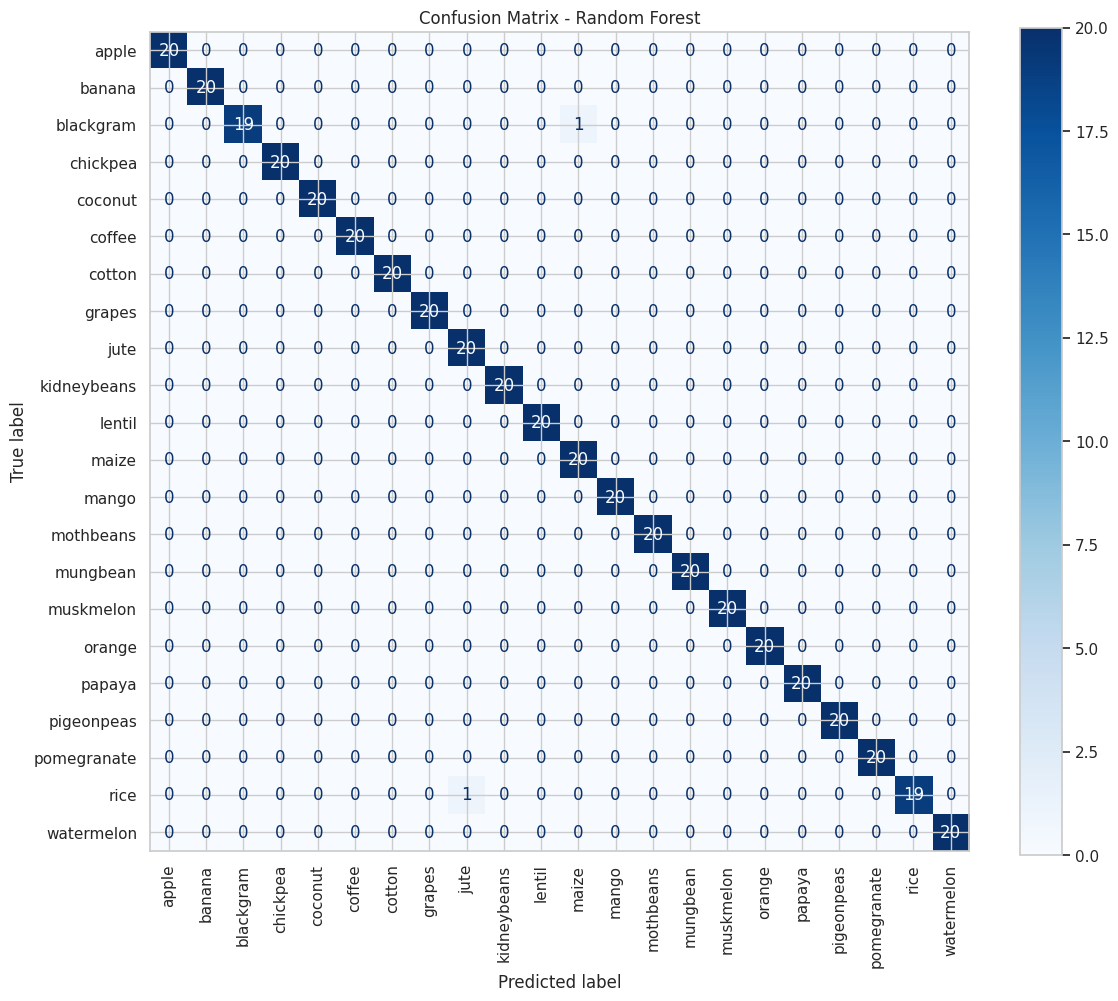

In [71]:
# Print classification report
print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
cm_display = ConfusionMatrixDisplay.from_predictions(
    y_test_encoded, y_pred, display_labels=le.classes_,
    cmap='Blues', xticks_rotation='vertical', ax=ax
)
plt.title(f"Confusion Matrix - {final_model_name}")
plt.tight_layout()
plt.show()

## 13. Explainability
### Feature Importance

/tmp/ipykernel_2771/2994301395.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


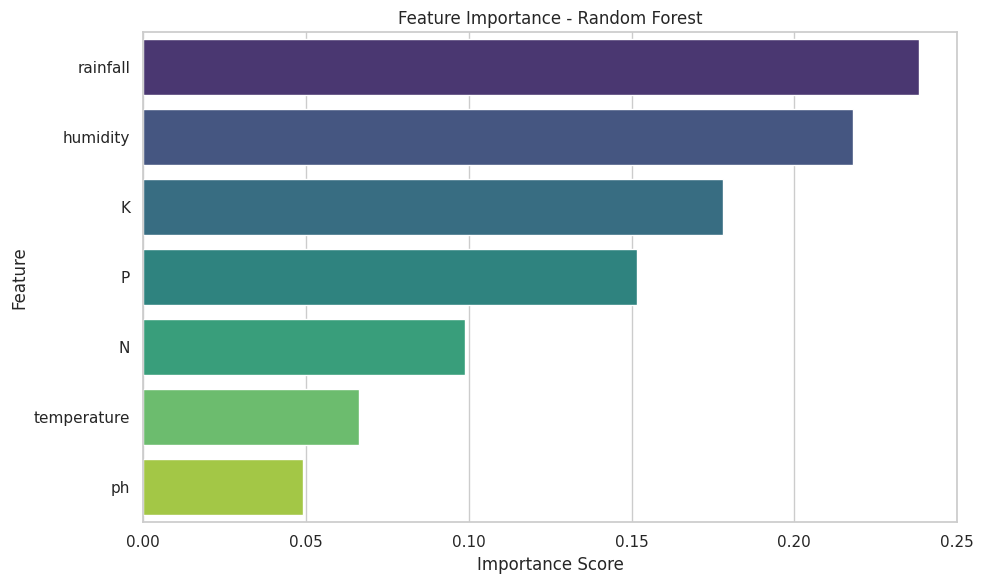

In [72]:
# Extract feature importances
importances = final_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title(f"Feature Importance - {final_model_name}")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### SHAP

Available classes:
['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']

Explaining class: rice
Class index: 20

X_test shape: (440, 7)
SHAP shape: (440, 7)


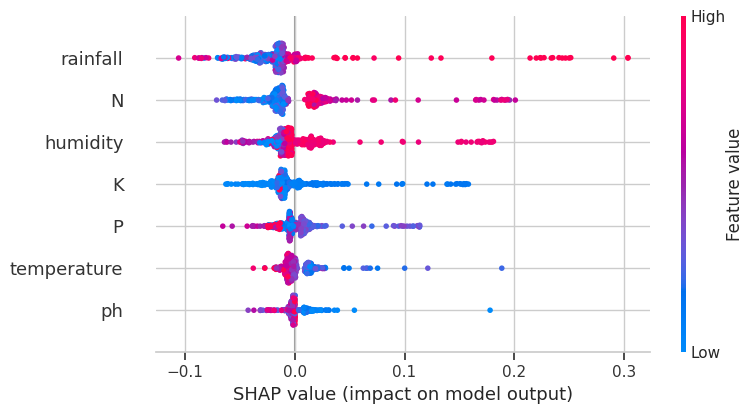

In [74]:
# ============================================
# SHAP Explainability - Multiclass Model
# ============================================

import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.TreeExplainer(final_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Display class names
print("Available classes:")
print(le.classes_)

# Select the crop we want to explain
class_name = "rice"

# Find class index
class_index = list(le.classes_).index(class_name)

print("\nExplaining class:", class_name)
print("Class index:", class_index)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    class_shap_values = shap_values[class_index]
else:
    class_shap_values = shap_values[:, :, class_index]

print("\nX_test shape:", X_test.shape)
print("SHAP shape:", class_shap_values.shape)

# SHAP summary plot
shap.summary_plot(
    class_shap_values,
    X_test,
    feature_names=X_test.columns
)

## 14. MLflow Tracking

In [77]:
# Track metrics, parameters, and model artifact using MLflow
mlflow.set_experiment("crop_classification_experiment")

with mlflow.start_run(
    run_name=f"final_{final_model_name.lower().replace(' ', '_')}"
):

    # Log parameters based on selection
    if final_model_name == "Random Forest":
        mlflow.log_params(best_rf_model.get_params())
    else:
        mlflow.log_params(best_xgb_model.get_params())

    # Log evaluation metrics
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("weighted_f1", f1_weighted)
    mlflow.log_metric("macro_f1", f1_macro)

    # Log model
    mlflow.sklearn.log_model(
        final_model,
        name="model",
        skops_trusted_types=["sklearn.tree._tree.Tree"]
    )

    print("Successfully logged parameters, metrics, and model to MLflow.")

Successfully logged parameters, metrics, and model to MLflow.


## 15. Save Final Model

In [76]:
# Serialize model and label encoder onto disk
import joblib

joblib.dump(final_model, "final_crop_model.joblib")
joblib.dump(le, "label_encoder.joblib")

print("Successfully saved final model and label encoder configuration!")

Successfully saved final model and label encoder configuration!
